In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Import CoolTrack modules
from cooltrack.constants import INDEPENDENT_DIMS
from cooltrack.data_loader import load_grid
from cooltrack.models import ThermalEvolutionModels

# Plotting style
sns.set_theme(style="whitegrid", context="talk")

# Data Path
GRID_FILE_PATH = "../data/HADES_grid/hades_processed_grid.parquet"
GRID_FILE_PATH = "../../exoweave/outputs/master_grid_data.h5"

In [2]:
print("Loading data...")
# Load the data using our optimized PyArrow loader
df = load_grid(GRID_FILE_PATH)

# For rapid evaluation testing, we can use a slice or the full dataset.
# Let's use the full loaded dataset here.
print(f"Data loaded successfully! Shape: {df.shape}")

2026-03-05 18:30:49,085 - INFO - Loading filtered parquet file: ../../exoweave/outputs/master_grid_data.h5...


Loading data...


ArrowInvalid: Could not open Parquet input source '<Buffer>': Parquet magic bytes not found in footer. Either the file is corrupted or this is not a parquet file.

In [ ]:
print("Training models and cleaning data...")
ml_engine = ThermalEvolutionModels()

# Capture the cleaned dataframe that the model returns!
df_clean = ml_engine.train_models(df, tune_hyperparameters=False, clean_outliers=True)

# NOW split the test sets using the CLEANED data
X_tint = df_clean[INDEPENDENT_DIMS + ['S_physical']]
y_tint = df_clean['T_int']
_, X_tint_test, _, y_tint_test = train_test_split(X_tint, y_tint, test_size=0.2, random_state=42)

X_dsdt = df_clean[INDEPENDENT_DIMS + ['S_physical', 'T_int']]
y_dsdt = df_clean['abs_log_dsdt']
_, X_dsdt_test, _, y_dsdt_test = train_test_split(X_dsdt, y_dsdt, test_size=0.2, random_state=42)

# Generate predictions on the unseen CLEAN test data
tint_preds = ml_engine.tint_model.predict(X_tint_test)
dsdt_preds = ml_engine.dsdt_model.predict(X_dsdt_test)
print("Predictions generated on clean data!")

2026-03-05 16:55:35,089 - INFO - Performing first-pass training to identify grid outliers...


Training models and cleaning data...


2026-03-05 16:55:36,727 - INFO - Dropping 1834 corrupted grid points (> 1.0 dex error).
2026-03-05 16:55:36,754 - INFO - Training T_int and Radius state models...
2026-03-05 16:55:48,281 - INFO - Training 15 photometric band models (this will take a minute)...
2026-03-05 16:56:33,028 - INFO - All photometry models trained successfully!
2026-03-05 16:56:33,042 - INFO - Training final baseline dS/dt model...
2026-03-05 16:56:41,872 - INFO - Final dS/dt test R^2: 0.9931


Predictions generated on clean data!


In [ ]:
print("=== T_int Model Evaluation ===")
print(f"R^2 Score: {r2_score(y_tint_test, tint_preds):.4f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_tint_test, tint_preds):.2f} K")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_tint_test, tint_preds)):.2f} K")

print("\n=== dS/dt Model Evaluation (Log10 scale) ===")
print(f"R^2 Score: {r2_score(y_dsdt_test, dsdt_preds):.4f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_dsdt_test, dsdt_preds):.4f} dex")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_dsdt_test, dsdt_preds)):.4f} dex")

=== T_int Model Evaluation ===
R^2 Score: 0.9643
Mean Absolute Error (MAE): 32.19 K
Root Mean Squared Error (RMSE): 59.91 K

=== dS/dt Model Evaluation (Log10 scale) ===
R^2 Score: 0.9931
Mean Absolute Error (MAE): 0.0343 dex
Root Mean Squared Error (RMSE): 0.1029 dex


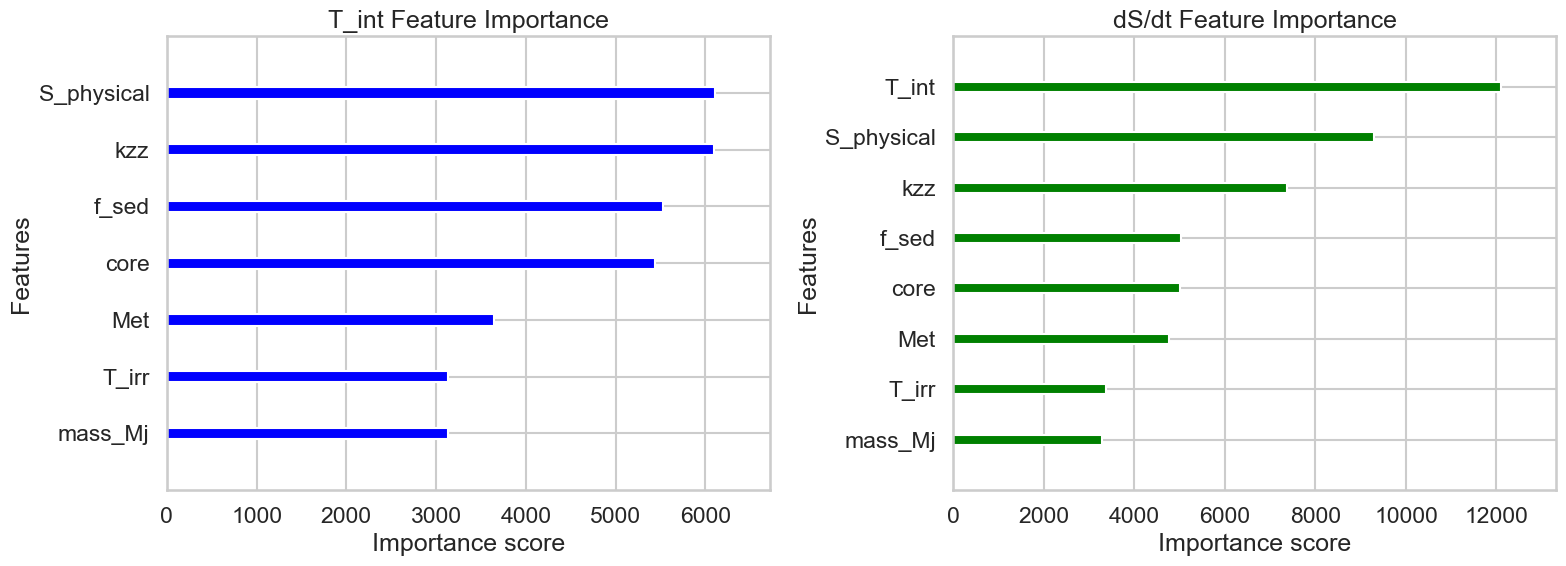

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# T_int Feature Importances
xgb.plot_importance(ml_engine.tint_model, ax=axes[0], importance_type='weight', 
                    title='T_int Feature Importance', color='blue', show_values=False)
axes[0].set_yticklabels(X_tint_test.columns)

# dS/dt Feature Importances
xgb.plot_importance(ml_engine.dsdt_model, ax=axes[1], importance_type='weight', 
                    title='dS/dt Feature Importance', color='green', show_values=False)
axes[1].set_yticklabels(X_dsdt_test.columns)

plt.tight_layout()
plt.show()

=== The Top 10 Worst Predictions ===


,mass_Mj,T_int,True_log_dsdt,Pred_log_dsdt,Error_dex
33171,0.158980,152.897099,-17.918101,-10.881232,7.036869
33878,0.352402,971.943223,-12.779344,-8.428230,4.351114
27259,0.331971,964.974635,-12.682569,-8.559914,4.122656
7751,1.564507,158.812911,-13.372365,-11.017578,2.354787
17820,2.833606,241.237454,-13.054487,-11.169897,1.884590
300,0.043392,1078.600753,-6.636581,-8.484820,1.848239
313,0.044350,1078.407652,-6.638461,-8.484097,1.845637
72672,0.669048,374.165622,-9.776206,-11.413267,1.637061
13458,2.083293,210.406150,-13.146239,-11.713207,1.433032
33736,0.351329,960.180314,-8.123317,-9.512274,1.388957


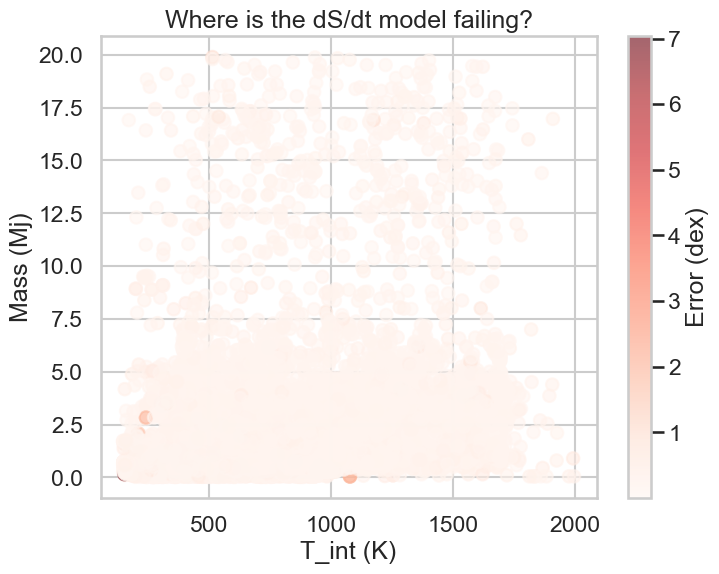

In [ ]:
# Calculate absolute errors
dsdt_errors = np.abs(y_dsdt_test - dsdt_preds)

# Attach errors back to the test dataframe
error_df = X_dsdt_test.copy()
error_df['True_log_dsdt'] = y_dsdt_test
error_df['Pred_log_dsdt'] = dsdt_preds
error_df['Error_dex'] = dsdt_errors

# Sort by the worst errors
worst_offenders = error_df.sort_values(by='Error_dex', ascending=False)

print("=== The Top 10 Worst Predictions ===")
display(worst_offenders[['mass_Mj', 'T_int', 'True_log_dsdt', 'Pred_log_dsdt', 'Error_dex']].head(10))

# Plot where the errors are happening
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(error_df['T_int'], error_df['mass_Mj'], c=error_df['Error_dex'], cmap='Reds', alpha=0.6)
plt.colorbar(scatter, label='Error (dex)')
ax.set_xlabel('T_int (K)')
ax.set_ylabel('Mass (Mj)')
ax.set_title('Where is the dS/dt model failing?')
plt.show()